This prepares the preprocessed SMS messages for the GRU deep learning model

1. Load the preprocessed dataset
2. Select the GRU text and target columns
3. Split the dataset into training and testing sets
4. Create and fit a tokenizer
5. Convert messages into integer sequences
6. Analyze sequence lengths
7. Apply padding and truncation
8. Save the tokenizer, configuration and prepared arrays

are the main steps I plan to do.

In [4]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

print("Libraries imported successfully")

Libraries imported successfully


In [5]:
data_path = "../data/preprocessed_sms_spam.csv"

df = pd.read_csv(data_path)

print("Dataset loaded successfully.")
print("Dataset shape:", df.shape)

df.head()

Dataset loaded successfully.
Dataset shape: (5044, 11)


,label,message,character_count,word_count,sentence_count,original_message,clean_message,clean_char_length,clean_word_count,gru_message,label_encoded
0,ham,"Go until jurong point, crazy.. Available only ...",111,24,2,"Go until jurong point, crazy.. Available only ...",go jurong point crazy available bugis great wo...,78,14,go until jurong point crazy available only in ...,0
1,ham,Ok lar... Joking wif u oni...,29,8,2,Ok lar... Joking wif u oni...,ok lar joking wif oni,21,5,ok lar joking wif u oni,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry wkly comp win fa cup final tkts st ...,99,20,free entry in a wkly comp to win fa cup final ...,1
3,ham,U dun say so early hor... U c already then say...,49,13,1,U dun say so early hor... U c already then say...,dun say early hor already say,29,6,u dun say so early hor u c already then say,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",61,15,1,"Nah I don't think he goes to usf, he lives aro...",nah think go usf life around though,35,7,nah i don t think he goes to usf he lives arou...,0


In [6]:
print(df.columns.tolist())

['label', 'message', 'character_count', 'word_count', 'sentence_count', 'original_message', 'clean_message', 'clean_char_length', 'clean_word_count', 'gru_message', 'label_encoded']


In [7]:
text_column = "gru_message"
target_column = "label_encoded"

X = df[text_column].fillna("").astype(str)
y = df[target_column].astype(int)

print("Number of messages:", len(X))

print("\nClass distribution:")
print(y.value_counts())

Number of messages: 5044

Class distribution:
label_encoded
0    4465
1     579
Name: count, dtype: int64


In [9]:
print("GRU missing messages:", df[text_column].isna().sum())
print("Missed labels:", df[target_column].isna().sum())

empty_messages = X.str.strip().eq("").sum()

print("Empty GRU messages:", empty_messages)

GRU missing messages: 0
Missed labels: 0
Empty GRU messages: 0


In [10]:
X_train_text, X_test_text, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training messages:", len(X_train_text))
print("Testing messages:", len(X_test_text))

print("\nTraining class distribution:")
print(y_train.value_counts())

print("\nTesting class distribution:")
print(y_test.value_counts())

Training messages: 4035
Testing messages: 1009

Training class distribution:
label_encoded
0    3572
1     463
Name: count, dtype: int64

Testing class distribution:
label_encoded
0    893
1    116
Name: count, dtype: int64


In [11]:
print(
    "Training percentage:",
    round(len(X_train_text) / len(X) * 100, 2),
    "%"
)

print(
    "Testing percentage:",
    round(len(X_test_text) / len(X) * 100, 2),
    "%"
)

Training percentage: 80.0 %
Testing percentage: 20.0 %


In [12]:
MAX_WORDS = 10000
OOV_TOKEN = "<OOV>"

tokenizer = Tokenizer(
    num_words=MAX_WORDS,
    oov_token=OOV_TOKEN
)

print("Tokenizer created successfully.")

Tokenizer created successfully.


In [13]:
tokenizer.fit_on_texts(X_train_text)

print("Tokenizer fitted successfully.")
print("Total words discovered:", len(tokenizer.word_index))

Tokenizer fitted successfully.
Total words discovered: 6823


In [14]:
first_words = list(tokenizer.word_index.items())[:20]

print("First 20 vocabulary entries:\n")

for word, index in first_words:
    print(f"{word} -> {index}")

First 20 vocabulary entries:

<OOV> -> 1
i -> 2
you -> 3
to -> 4
a -> 5
the -> 6
u -> 7
and -> 8
in -> 9
is -> 10
me -> 11
my -> 12
it -> 13
for -> 14
your -> 15
of -> 16
that -> 17
s -> 18
have -> 19
on -> 20


In [16]:
VOCAB_SIZE = min(
    MAX_WORDS,
    len(tokenizer.word_index) + 1
)

print("Vocabulary size - ", VOCAB_SIZE)

Vocabulary size -  6824


In [17]:
X_train_sequences = tokenizer.texts_to_sequences(X_train_text)
X_test_sequences = tokenizer.texts_to_sequences(X_test_text)

print("Training msg:", len(X_train_sequences))
print("Testing msg:", len(X_test_sequences))

Training msg: 4035
Testing msg: 1009


In [18]:
sample_index = 0

print("Original GRU message:")
print(X_train_text.iloc[sample_index])

print("\nInteger sequence:")
print(X_train_sequences[sample_index])

print("\nSequence length:")
print(len(X_train_sequences[sample_index]))

Original GRU message:
i told her i had a dr appt next week she thinks i m gonna die i told her its just a check nothing to be worried about but she didn t listen

Integer sequence:
[2, 220, 110, 2, 145, 5, 2156, 1682, 189, 120, 93, 870, 2, 24, 207, 694, 2, 220, 110, 66, 38, 5, 298, 299, 4, 33, 786, 82, 28, 93, 275, 21, 871]

Sequence length:
33


In [19]:
train_sequence_lengths = [
    len(sequence)
    for sequence in X_train_sequences
]

sequence_length_series = pd.Series(train_sequence_lengths)

print(sequence_length_series.describe())

count    4035.000000
mean       15.507311
std        10.862878
min         1.000000
25%         8.000000
50%        12.000000
75%        22.000000
max       190.000000
dtype: float64


In [20]:
print(
    sequence_length_series.describe(
        percentiles=[0.90, 0.95, 0.99]
    )
)

count    4035.000000
mean       15.507311
std        10.862878
min         1.000000
90%        29.000000
95%        33.000000
99%        50.660000
max       190.000000
dtype: float64


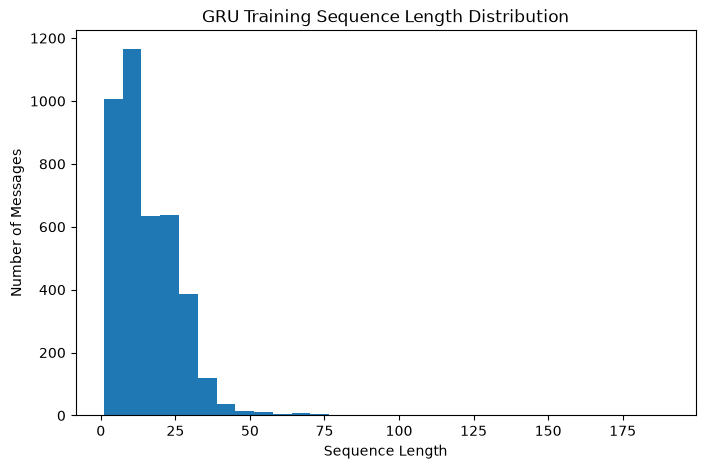

In [21]:
plt.figure(figsize=(8, 5))

plt.hist(
    train_sequence_lengths,
    bins=30
)

plt.xlabel("Sequence Length")
plt.ylabel("Number of Messages")
plt.title("GRU Training Sequence Length Distribution")

plt.show()

In [22]:
MAX_LENGTH = max(
    1,
    int(np.percentile(train_sequence_lengths, 95))
)

print("Selected maximum sequence length:", MAX_LENGTH)

Selected maximum sequence length: 33


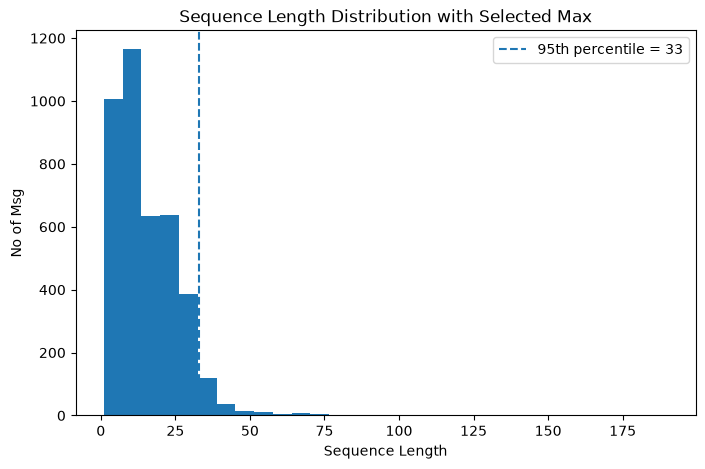

In [23]:
plt.figure(figsize=(8, 5))

plt.hist(
    train_sequence_lengths,
    bins=30
)

plt.axvline(
    MAX_LENGTH,
    linestyle="--",
    label=f"95th percentile = {MAX_LENGTH}"
)

plt.xlabel("Sequence Length")
plt.ylabel("No of Msg")
plt.title("Sequence Length Distribution with Selected Max")
plt.legend()

plt.show()

In [24]:
X_train_padded = pad_sequences(
    X_train_sequences,
    maxlen=MAX_LENGTH,
    padding="post",
    truncating="post"
)

X_test_padded = pad_sequences(
    X_test_sequences,
    maxlen=MAX_LENGTH,
    padding="post",
    truncating="post"
)

print("Padding completed.")

print("Training shape:", X_train_padded.shape)
print("Testing shape:", X_test_padded.shape)

Padding completed.
Training shape: (4035, 33)
Testing shape: (1009, 33)


In [25]:
print("Original sequence:")
print(X_train_sequences[0])

print("\nPadded sequence:")
print(X_train_padded[0])

print("\nPadded sequence length:")
print(len(X_train_padded[0]))

Original sequence:
[2, 220, 110, 2, 145, 5, 2156, 1682, 189, 120, 93, 870, 2, 24, 207, 694, 2, 220, 110, 66, 38, 5, 298, 299, 4, 33, 786, 82, 28, 93, 275, 21, 871]

Padded sequence:
[   2  220  110    2  145    5 2156 1682  189  120   93  870    2   24
  207  694    2  220  110   66   38    5  298  299    4   33  786   82
   28   93  275   21  871]

Padded sequence length:
33


In [27]:
y_train_array = y_train.to_numpy(dtype=np.int32)
y_test_array = y_test.to_numpy(dtype=np.int32)

print("Training shape:", y_train_array.shape)
print("Testing shape:", y_test_array.shape)

Training shape: (4035,)
Testing shape: (1009,)


In [28]:
assert X_train_padded.shape[0] == y_train_array.shape[0]
assert X_test_padded.shape[0] == y_test_array.shape[0]

assert X_train_padded.shape[1] == MAX_LENGTH
assert X_test_padded.shape[1] == MAX_LENGTH

assert X_train_padded.dtype in [np.int32, np.int64]
assert X_test_padded.dtype in [np.int32, np.int64]

print("All GRU preparation checks passed successfully.")

All GRU preparation checks passed successfully.


In [29]:
os.makedirs("../models", exist_ok=True)
os.makedirs("../data", exist_ok=True)

print("Required folders are ready")

Required folders are ready


In [30]:
tokenizer_json = tokenizer.to_json()

with open(
    "../models/gru_tokenizer.json",
    "w",
    encoding="utf-8"
) as file:
    file.write(tokenizer_json)

print("Tok.saved successfully.")

Tok.saved successfully.


In [31]:
gru_config = {
    "max_words": MAX_WORDS,
    "vocab_size": VOCAB_SIZE,
    "max_length": MAX_LENGTH,
    "padding": "post",
    "truncating": "post",
    "oov_token": OOV_TOKEN
}

with open(
    "../models/gru_sequence_config.json",
    "w",
    encoding="utf-8"
) as file:
    json.dump(gru_config, file, indent=4)

print("configuration saved successfully.")
print(gru_config)

configuration saved successfully.
{'max_words': 10000, 'vocab_size': 6824, 'max_length': 33, 'padding': 'post', 'truncating': 'post', 'oov_token': '<OOV>'}


In [32]:
np.savez_compressed(
    "../data/gru_prepared_data.npz",
    X_train=X_train_padded,
    X_test=X_test_padded,
    y_train=y_train_array,
    y_test=y_test_array
)

print("GRU arrays saved successfully.")

GRU arrays saved successfully.


In [33]:
gru_train_data = pd.DataFrame({
    "gru_message": X_train_text,
    "label_encoded": y_train
}).reset_index(drop=True)

gru_test_data = pd.DataFrame({
    "gru_message": X_test_text,
    "label_encoded": y_test
}).reset_index(drop=True)

gru_train_data.to_csv(
    "../data/gru_train_data.csv",
    index=False
)

gru_test_data.to_csv(
    "../data/gru_test_data.csv",
    index=False
)

print("GRU training data saved:", gru_train_data.shape)
print("GRU testing data saved:", gru_test_data.shape)

GRU training data saved: (4035, 2)
GRU testing data saved: (1009, 2)


In [35]:
saved_data = np.load("../data/gru_prepared_data.npz")

print("Data loaded successfully.")

print("X_train shape:", saved_data["X_train"].shape)
print("X_test shape:", saved_data["X_test"].shape)
print("y_train shape:", saved_data["y_train"].shape)
print("y_test shape:", saved_data["y_test"].shape)

Data loaded successfully.
X_train shape: (4035, 33)
X_test shape: (1009, 33)
y_train shape: (4035,)
y_test shape: (1009,)


In [36]:
with open(
    "../models/gru_sequence_config.json",
    "r",
    encoding="utf-8"
) as file:
    loaded_config = json.load(file)

print("Loaded GRU configuration:")
print(loaded_config)

Loaded GRU configuration:
{'max_words': 10000, 'vocab_size': 6824, 'max_length': 33, 'padding': 'post', 'truncating': 'post', 'oov_token': '<OOV>'}


This is the final summary cell for easy to understand.

In [37]:
print("GRU SEQUENCE PREPARATION SUMMARY")
print("=" * 55)

print("Total messages:", len(X))
print("Training messages:", len(X_train_text))
print("Testing messages:", len(X_test_text))

print("Vocabulary size:", VOCAB_SIZE)
print("Maximum sequence length:", MAX_LENGTH)

print("Training padded shape:", X_train_padded.shape)
print("Testing padded shape:", X_test_padded.shape)

print("Training label shape:", y_train_array.shape)
print("Testing label shape:", y_test_array.shape)

print("\nTokenizer saved successfully.")
print("Configuration saved successfully.")
print("Prepared arrays saved successfully.")

print("\nNext step: Train the GRU model.")

GRU SEQUENCE PREPARATION SUMMARY
Total messages: 5044
Training messages: 4035
Testing messages: 1009
Vocabulary size: 6824
Maximum sequence length: 33
Training padded shape: (4035, 33)
Testing padded shape: (1009, 33)
Training label shape: (4035,)
Testing label shape: (1009,)

Tokenizer saved successfully.
Configuration saved successfully.
Prepared arrays saved successfully.

Next step: Train the GRU model.
